# Часть 1

## Этап 1

### Импорты библиотек

Сначала импортируем библиотеки, необходимые для работы над проектом.

In [1]:
# импортируем базовые библиотеки для работы с данными
import os
import random
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# импортируем статистические инструменты
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# импортируем инструменты для подготовки данных
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# импортируем базовые алгоритмы машинного обучения
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# импортируем uplift-модели
from causalml.inference.meta import (
    BaseSClassifier,
    BaseTClassifier,
    BaseXClassifier,
    BaseRClassifier,
)
from causalml.inference.tree import UpliftRandomForestClassifier

# импортируем метрики для оценки uplift-моделей
from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    uplift_at_k,
)

# импортируем инструменты для подбора гиперпараметров
import optuna

# отключаем информационные сообщения Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# импортируем MLflow для логирования экспериментов
import mlflow

# импортируем вспомогательные функции проекта
import utils

# импортируем инструменты для работы с предупреждениями
import warnings

# импортируем progress bar для длительных вычислений
from tqdm.auto import tqdm

Также сразу зададим общие параметры для воспроизводимости результатов и настроим более читабельное отображение числовых значений в таблицах.

In [2]:
# задаём random state для воспроизводимости результатов
RANDOM_STATE = 42

# настраиваем отображение чисел с тремя знаками после запятой
pd.set_option("display.float_format", "{:,.3f}".format)

# настраиваем отображение всех столбцов в таблицах
pd.set_option("display.max_columns", None)

Также загрузим переменные окружения, необходимые для подключения MLflow к S3-хранилищу, и проверим их доступность.

In [3]:
# задаём путь к файлу с переменными окружения
ENV_PATH = Path(
    "/home/mle-user/mle_projects/mle-mlflow-tatplet/.env"
)

# загружаем переменные окружения
load_dotenv(ENV_PATH)

# задаём endpoint Yandex Object Storage для MLflow
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"

# проверяем наличие переменных для доступа к S3
for var in [
    "MLFLOW_S3_ENDPOINT_URL",
    "AWS_ACCESS_KEY_ID",
    "AWS_SECRET_ACCESS_KEY"
]:
    status = "SET" if os.getenv(var) else "MISSING"
    print(f"{var}: {status}")

MLFLOW_S3_ENDPOINT_URL: SET
AWS_ACCESS_KEY_ID: SET
AWS_SECRET_ACCESS_KEY: SET


Необходимые библиотеки успешно импортированы, заданы параметры воспроизводимости и формат дальнейшего отображения данных, а также настроен доступ к S3-хранилищу для логирования артефактов в MLflow. Таким образом, окружение готово для дальнейшей работы с данными, построения uplift-моделей, подбора гиперпараметров и логирования экспериментов.

### Загрузка данных

Теперь задаём путь к исходным данным, проверяем существование файла и загружаем датасет для дальнейшего анализа.

In [4]:
# задаём путь к исходному датасету
DATA_PATH = Path("uplift_fp_data.csv")

In [5]:
# проверяем существование файла с данными
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Файл не найден: {DATA_PATH.resolve()}")

# загружаем датасет и делаем проверку
data = pd.read_csv(DATA_PATH)
data.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.440,1,0,1,0,1,1,0
1,6,2,329.080,1,1,2,1,2,0,0
2,7,1,180.650,0,1,1,1,2,1,0
3,9,4,675.830,1,0,2,1,2,0,0
4,2,0,45.340,1,0,0,0,2,1,0


Датасет успешно загружен. В данных представлены признаки поведения и характеристик клиентов, индикатор воздействия `treatment` и целевая переменная `target`.

### Первичное знакомство с данными

Проверим размер датасета, типы данных, количество пропусков и дубликатов, чтобы оценить качество исходных данных перед дальнейшим анализом.

In [6]:
# создаём функцию, позволяющую произвести быстрое знакомство с данными
def explo_data(df: pd.DataFrame, n: int = 5):
    """
    Быстрый обзор датафрейма: head, размеры, столбцы, типы, пропуски, дубликаты, статистика.
    Параметры:
        - df (pd.DataFrame): датафрейм для анализа
        - n (int): сколько строк показывать в выборках (по умолчанию = 5)
    Пример:
        explo_data(train_df, n=10)
    """

    print("-" * 110)
    print("Первые строки:")
    display(df.head(n))

    print("-" * 110)
    print("Размеры датафрейма:")
    print(f"Строк: {df.shape[0]:,} | Столбцов: {df.shape[1]}")

    print("-" * 110)
    print("Названия столбцов:")
    print(list(df.columns))

    print("-" * 110)
    print("Информация о датафрейме:")
    df.info()

    print("-" * 110)
    print("Пропущенные значения (кол-во и %, отсортировано по убыванию):")
    missing_data = (
        df.isna()
        .sum()
        .to_frame(name="count")
        .assign(percent=lambda x: (x["count"] / len(df) * 100).round(2))
        .sort_values(by="count", ascending=False)
    )
    display(missing_data)

    print("-" * 110)
    print("Строки с пропущенными значениями (первые n строк):")
    display(df[df.isna().any(axis=1)].head(n))

    print("-" * 110)
    print("Явные дубликаты:")
    print(f"Количество дубликатов: {df.duplicated().sum():,}")

    print("-" * 110)
    print("Строки с явными дубликатами (первые n строк):")
    display(df[df.duplicated()].head(n))

    print("-" * 110)
    print("Описательная статистика:")
    display(df.describe(include="all"))

    print("-" * 110)

In [7]:
# выполняем первичную проверку качества данных с помощью созданной функции
explo_data(data)

--------------------------------------------------------------------------------------------------------------
Первые строки:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.440,1,0,1,0,1,1,0
1,6,2,329.080,1,1,2,1,2,0,0
2,7,1,180.650,0,1,1,1,2,1,0
3,9,4,675.830,1,0,2,1,2,0,0
4,2,0,45.340,1,0,0,0,2,1,0


--------------------------------------------------------------------------------------------------------------
Размеры датафрейма:
Строк: 64,000 | Столбцов: 10
--------------------------------------------------------------------------------------------------------------
Названия столбцов:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'treatment', 'target']
--------------------------------------------------------------------------------------------------------------
Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000

,count,percent
recency,0,0.000
history_segment,0,0.000
history,0,0.000
mens,0,0.000
womens,0,0.000
zip_code,0,0.000
newbie,0,0.000
channel,0,0.000
treatment,0,0.000
target,0,0.000


--------------------------------------------------------------------------------------------------------------
Строки с пропущенными значениями (первые n строк):


...

--------------------------------------------------------------------------------------------------------------
Явные дубликаты:
Количество дубликатов: 7,015
--------------------------------------------------------------------------------------------------------------
Строки с явными дубликатами (первые n строк):


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
149,2,0,29.990,0,1,1,0,1,0,0
167,7,0,29.990,1,0,1,1,2,1,0
526,10,0,29.990,1,0,0,0,2,1,0
606,10,0,29.990,1,0,1,1,2,0,0
654,10,0,29.990,1,0,0,0,2,1,0


--------------------------------------------------------------------------------------------------------------
Описательная статистика:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,"64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000"
mean,5.764,1.482,242.086,0.551,0.550,0.748,0.502,1.320,0.334,0.147
std,3.508,1.545,256.159,0.497,0.498,0.698,0.500,0.678,0.472,0.354
min,1.000,0.000,29.990,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2.000,0.000,64.660,0.000,0.000,0.000,0.000,1.000,0.000,0.000
50%,6.000,1.000,158.110,1.000,1.000,1.000,1.000,1.000,0.000,0.000
75%,9.000,2.000,325.657,1.000,1.000,1.000,1.000,2.000,1.000,0.000
max,12.000,6.000,"3,345.930",1.000,1.000,2.000,1.000,2.000,1.000,1.000


--------------------------------------------------------------------------------------------------------------


Датасет содержит 64000 наблюдений и 10 признаков. Пропущенные значения отсутствуют, поэтому их дополнительная обработка не требуется. Все признаки представлены в числовом формате.

Обнаружено 7015 полностью совпадающих строк. Поскольку в данных отсутствует уникальный идентификатор клиента, такие совпадения нельзя однозначно считать ошибочными дубликатами: разные пользователи могут иметь одинаковые значения всех представленных признаков. Поэтому на данном этапе строки не удаляем и дополнительно исследуем их структуру на этапе EDA.

По описательной статистике видно, что около трети наблюдений относятся к группе воздействия (`treatment`), а общая доля положительного таргета составляет около 14.7%. Признак `history` имеет заметную правостороннюю асимметрию: среднее значение выше медианы, а максимальное значение существенно превышает верхний квартиль.

Проверим дополнительно уникальные значения дискретных признаков, чтобы убедиться в корректности их кодировки и отсутствии неожиданных категорий.

In [8]:
# создаём список дискретных признаков для проверки
discrete_features = [
    "recency",
    "history_segment",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
    "treatment",
    "target",
]

# выводим уникальные значения каждого дискретного признака
for feature in discrete_features:
    print(f"{feature}: {sorted(data[feature].unique())}")

recency: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
history_segment: [0, 1, 2, 3, 4, 5, 6]
mens: [0, 1]
womens: [0, 1]
zip_code: [0, 1, 2]
newbie: [0, 1]
channel: [0, 1, 2]
treatment: [0, 1]
target: [0, 1]


После проверки видим, что кодировки выглядят корректно и полностью соответствуют описанию датасета.

**Вывод**

<div style="border:solid lightblue 3px; padding: 20px">
    
Итак, на этапе первичной подготовки данных были импортированы необходимые библиотеки, загружен датасет и проведена базовая проверка его качества. В данных отсутствуют пропущенные значения и некорректные категории, поэтому дополнительное заполнение или исправление значений не требуется.

Обнаружены полностью совпадающие строки, однако из-за отсутствия уникального идентификатора клиента их нельзя однозначно интерпретировать как ошибочные дубликаты, поэтому они сохранены. Датасет готов к дальнейшему исследовательскому анализу (EDA).

## Этап 2

### EDA


Проанализируем размеры контрольной и тестовой групп и рассмотрим распределение целевой переменной. Это позволит оценить структуру A/B-теста и предварительно увидеть различия в конверсии между клиентами, получившими промокод, и контрольной группой.

In [9]:
# считаем количество наблюдений в контрольной и тестовой группах
treatment_counts = (
    data["treatment"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Контроль", 1: "Воздействие"})
)

In [10]:
# считаем распределение таргета внутри каждой экспериментальной группы
target_by_treatment = pd.crosstab(
    data["treatment"],
    data["target"]
).rename(
    index={0: "Контроль", 1: "Воздействие"},
    columns={0: "target = 0", 1: "target = 1"}
)

In [11]:
# рассчитываем долю положительного таргета в каждой группе
conversion_by_treatment = (
    data.groupby("treatment")["target"]
    .agg(["count", "mean"])
    .rename(index={0: "Контроль", 1: "Воздействие"})
    .rename(columns={"count": "Количество", "mean": "Конверсия"})
)

In [12]:
# выводим полученные результаты
print("Количество наблюдений по группам:")
display(treatment_counts.to_frame(name="Количество"))

print("Распределение target по группам:")
display(target_by_treatment)

print("Конверсия по группам:")
display(conversion_by_treatment)

Количество наблюдений по группам:


,Количество
treatment,
Контроль,42613
Воздействие,21387


Распределение target по группам:


target,target = 0,target = 1
treatment,,
Контроль,36457,6156
Воздействие,18149,3238


Конверсия по группам:


,Количество,Конверсия
treatment,,
Контроль,42613,0.144
Воздействие,21387,0.151


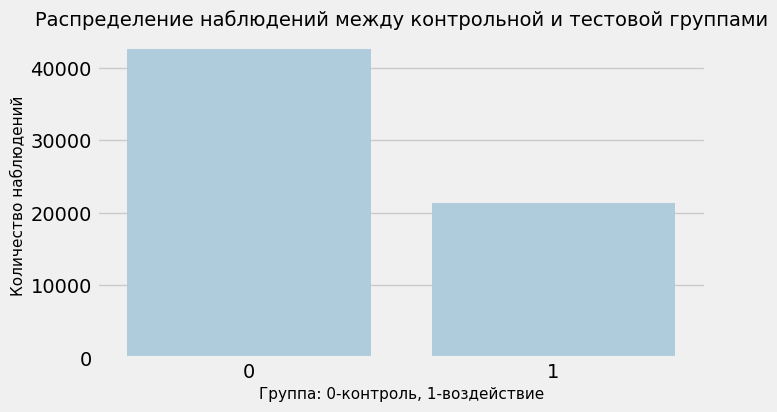

In [13]:
# создаём визуализацию размера экспериментальных групп
plt.figure(figsize=(7, 4))
sns.countplot(
    data=data,
    x="treatment"
)
plt.title("Распределение наблюдений между контрольной и тестовой группами", fontsize=14)
plt.xlabel("Группа: 0-контроль, 1-воздействие", fontsize=11)
plt.ylabel("Количество наблюдений", fontsize=11)
plt.show()

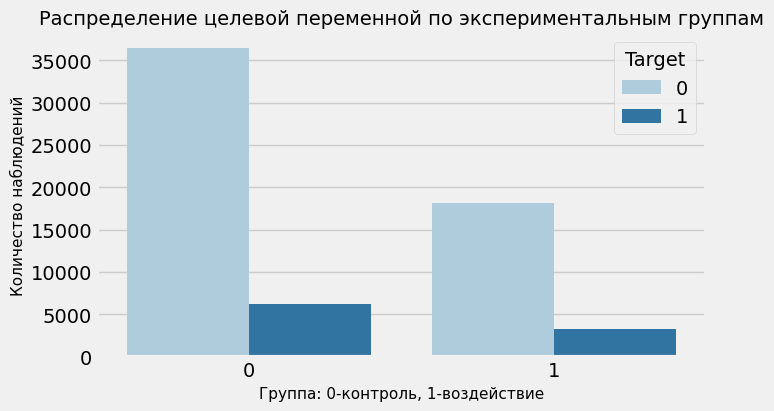

In [14]:
# создаём визуализацию распределения таргета по экспериментальным группам
plt.figure(figsize=(7, 4))
sns.countplot(
    data=data,
    x="treatment",
    hue="target"
)
plt.title("Распределение целевой переменной по экспериментальным группам", fontsize=14)
plt.xlabel("Группа: 0-контроль, 1-воздействие", fontsize=11)
plt.ylabel("Количество наблюдений", fontsize=11)
plt.legend(title="Target")
plt.show()

Контрольная группа содержит 42613 наблюдений, а группа воздействия 21387, то есть выборка распределена между группами примерно в соотношении 2:1. Такая несбалансированность по размеру групп допустима, поскольку обе группы достаточно велики для дальнейшего анализа. Доля положительного таргета в контрольной группе составляет 14.4%, а в группе воздействия 15.1%.

Таким образом, в группе клиентов, получивших промокод, наблюдается небольшое увеличение конверсии примерно на 0.7 процентного пункта. Однако на данном этапе это только наблюдаемое различие: его статистическую значимость необходимо проверить отдельно в следующей главе.

Проверим, насколько контрольная и тестовая группы сопоставимы по основным исходным признакам. Это позволит убедиться, что наблюдаемая разница в конверсии не сопровождается выраженными различиями в характеристиках клиентов между группами.

In [15]:
# создаём список признаков для проверки сопоставимости групп
balance_features = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
]

In [16]:
# рассчитываем средние значения признаков отдельно для контрольной и тестовой групп
group_balance = (
    data.groupby("treatment")[balance_features]
    .mean()
    .T
    .rename(columns={0: "Контроль", 1: "Воздействие"}))

In [17]:
# рассчитываем абсолютную разницу между средними значениями групп
group_balance["Разница"] = (group_balance["Воздействие"] - group_balance["Контроль"])

In [18]:
# выводим таблицу для сравнения групп
display(group_balance)

treatment,Контроль,Воздействие,Разница
recency,5.762,5.768,0.006
history_segment,1.480,1.486,0.006
history,241.859,242.537,0.677
mens,0.552,0.549,-0.003
womens,0.550,0.550,0.001
zip_code,0.748,0.749,0.000
newbie,0.502,0.503,0.002
channel,1.321,1.317,-0.004


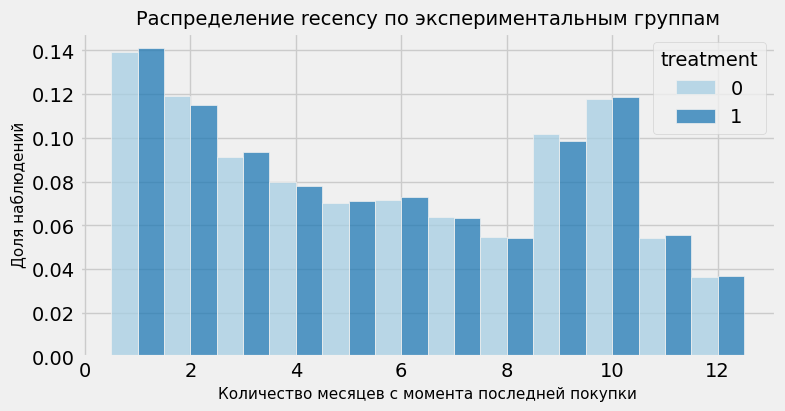

In [19]:
# строим распределение recency по экспериментальным группам
plt.figure(figsize=(8, 4))
sns.histplot(
    data=data,
    x="recency",
    hue="treatment",
    discrete=True,
    stat="probability",
    common_norm=False,
    multiple="dodge")
plt.title("Распределение recency по экспериментальным группам", fontsize=14)
plt.xlabel("Количество месяцев с момента последней покупки", fontsize=11)
plt.ylabel("Доля наблюдений", fontsize=11)
plt.show()

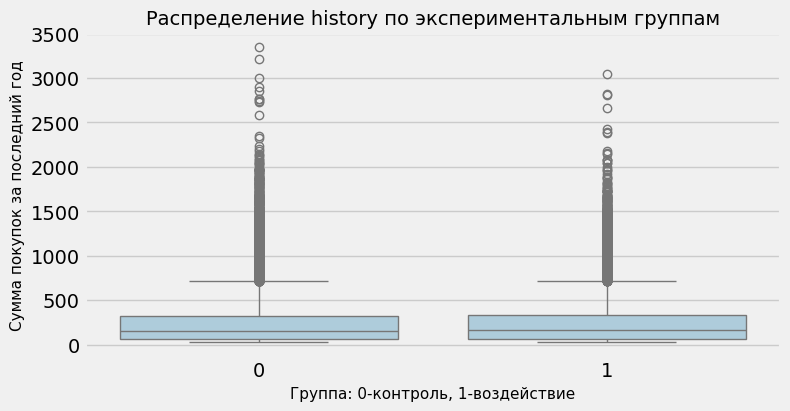

In [20]:
# строим распределение history по экспериментальным группам
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=data,
    x="treatment",
    y="history")
plt.title("Распределение history по экспериментальным группам", fontsize=14)
plt.xlabel("Группа: 0-контроль, 1-воздействие", fontsize=11)
plt.ylabel("Сумма покупок за последний год", fontsize=11)
plt.show()

Контрольная и тестовая группы хорошо сопоставимы по исходным признакам: средние значения практически не отличаются друг от друга, а распределения `recency` и `history` визуально очень похожи. Выраженных систематических различий между группами не наблюдается, поэтому дальнейшее сравнение конверсии между ними выглядит вполне корректным. При этом признак `history` в обеих группах имеет заметную правостороннюю асимметрию и большое количество высоких значений, что стоит учитывать при дальнейшем анализе и возможном создании новых признаков (feature engineering).

По результатам EDA видно, что датасет имеет хорошее качество: пропуски и некорректные категории отсутствуют. Контрольная и тестовая группы различаются по размеру примерно в соотношении 2:1, однако обе группы достаточно велики для дальнейшего анализа.

Конверсия в контрольной группе составляет 14.4%, а в группе воздействия 15.1%, то есть наблюдается небольшой положительный эффект промокода примерно в 0.7 процентного пункта. При этом контрольная и тестовая группы хорошо сопоставимы по исходным признакам: средние значения и распределения основных характеристик практически совпадают.

Признак `history` имеет выраженную правостороннюю асимметрию и большое количество высоких значений, что стоит учитывать при дальнейшем моделировании и возможном feature engineering. Наблюдаемое различие в конверсии пока нельзя считать статистически значимым без отдельной проверки гипотез, поэтому переходим к проверке на статистическую значимость.

### Проверка на статистическую значимость

Проверим, является ли различие в конверсии между контрольной и тестовой группами статистически значимым. Поскольку целевая переменная `target` бинарная, а нас интересует сравнение долей успешной конверсии в двух независимых группах, используем двухвыборочный z-тест для пропорций.

Сформулируем гипотезы:

- **H₀:** доля положительного таргета в контрольной и тестовой группах одинакова.
- **H₁:** доля положительного таргета в контрольной и тестовой группах различается.

Уровень статистической значимости примем равным `alpha = 0.05`.

In [21]:
# задаём уровень статистической значимости
alpha = 0.05

In [22]:
# выделяем контрольную и тестовую группы
control_group = data[data["treatment"] == 0]["target"]
treatment_group = data[data["treatment"] == 1]["target"]

In [23]:
# рассчитываем средние значения и стандартные отклонения таргета по группам
group_stats = pd.DataFrame({
    "Группа": ["Контроль", "Воздействие"],
    "Среднее": [control_group.mean(), treatment_group.mean()],
    "Стандартное отклонение": [control_group.std(), treatment_group.std()],
    "Количество наблюдений": [len(control_group), len(treatment_group)],
})

In [24]:
# выводим описательные статистики по группам
display(group_stats)

,Группа,Среднее,Стандартное отклонение,Количество наблюдений
0,Контроль,0.144,0.352,42613
1,Воздействие,0.151,0.358,21387


Проверим выполнение предпосылок двухвыборочного z-теста для пропорций. Группы являются независимыми по дизайну A/B-теста, а количество положительных и отрицательных исходов в каждой группе должно быть достаточно большим для применения нормального приближения.

In [25]:
# рассчитываем количество положительных и отрицательных исходов в каждой группе и делаем проверку
test_assumptions = pd.DataFrame({
    "Группа": ["Контроль", "Воздействие"],
    "Положительные исходы": [
        control_group.sum(),
        treatment_group.sum()
    ],
    "Отрицательные исходы": [
        len(control_group) - control_group.sum(),
        len(treatment_group) - treatment_group.sum()
    ]
})
display(test_assumptions)

,Группа,Положительные исходы,Отрицательные исходы
0,Контроль,6156,36457
1,Воздействие,3238,18149


В обеих экспериментальных группах количество положительных и отрицательных исходов значительно превышает минимально необходимое для применения нормального приближения. Группы являются независимыми по дизайну A/B-теста, поэтому предпосылки двухвыборочного z-теста для пропорций выполняются.

In [26]:
# считаем число положительных исходов в каждой группе
successes = np.array([
    control_group.sum(),
    treatment_group.sum()
])

In [27]:
# считаем общее число наблюдений в каждой группе
nobs = np.array([
    len(control_group),
    len(treatment_group)
])

In [28]:
# выполняем двухвыборочный z-тест для пропорций
z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=nobs,
    alternative="two-sided"
)

In [29]:
# выводим результаты теста
print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"Уровень значимости: {alpha}")

z-статистика: -2.339
p-value: 0.019
Уровень значимости: 0.05


Полученное значение `p-value = 0.019` меньше выбранного уровня статистической значимости `alpha = 0.05`. Поэтому нулевая гипотеза об одинаковой доле положительного таргета в контрольной и тестовой группах отвергается.

Для визуального сравнения между группами построим график.

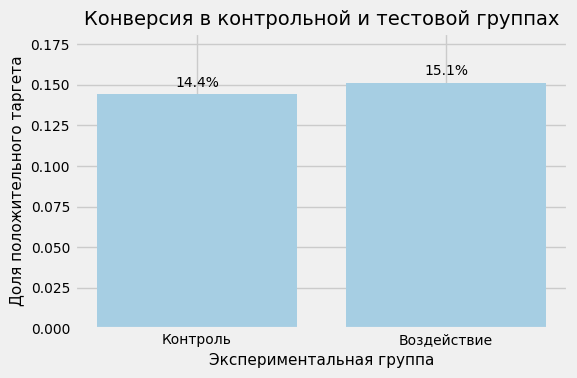

In [30]:
# рассчитываем конверсию по экспериментальным группам
conversion_rates = (
    data.groupby("treatment")["target"]
    .mean()
    .sort_index())

# создаём фигуру и оси
fig, ax = plt.subplots(figsize=(6, 4))

# строим столбчатую диаграмму
bars = ax.bar(
    ["Контроль", "Воздействие"],
    conversion_rates.values)

# добавляем значения конверсии над столбцами
ax.bar_label(
    bars,
    labels=[f"{value:.1%}" for value in conversion_rates.values],
    padding=3,
    fontsize=10)

# оформляем график
ax.set_title(
    "Конверсия в контрольной и тестовой группах",
    fontsize=14)
ax.set_xlabel("Экспериментальная группа", fontsize=11)
ax.set_ylabel("Доля положительного таргета", fontsize=11)
ax.set_ylim(0, conversion_rates.max() * 1.20)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

Таким образом, различие в конверсии между группами статистически значимо: в группе воздействия конверсия выше 15.1% против 14.4% в контрольной группе. При этом абсолютный эффект невелик и составляет около 0.7 процентного пункта, что дополнительно обосновывает необходимость uplift-моделирования для поиска пользователей, на которых воздействие работает наиболее эффективно.

### Корреляционный анализ

В этом разделе проанализируем линейные взаимосвязи между признаками и целевой переменной с помощью корреляционной матрицы. Это позволит определить наиболее выраженные связи между признаками, а также оценить, какие из них сильнее связаны с таргетом.

In [31]:
# рассчитываем корреляционную матрицу
corr_matrix = data.corr()

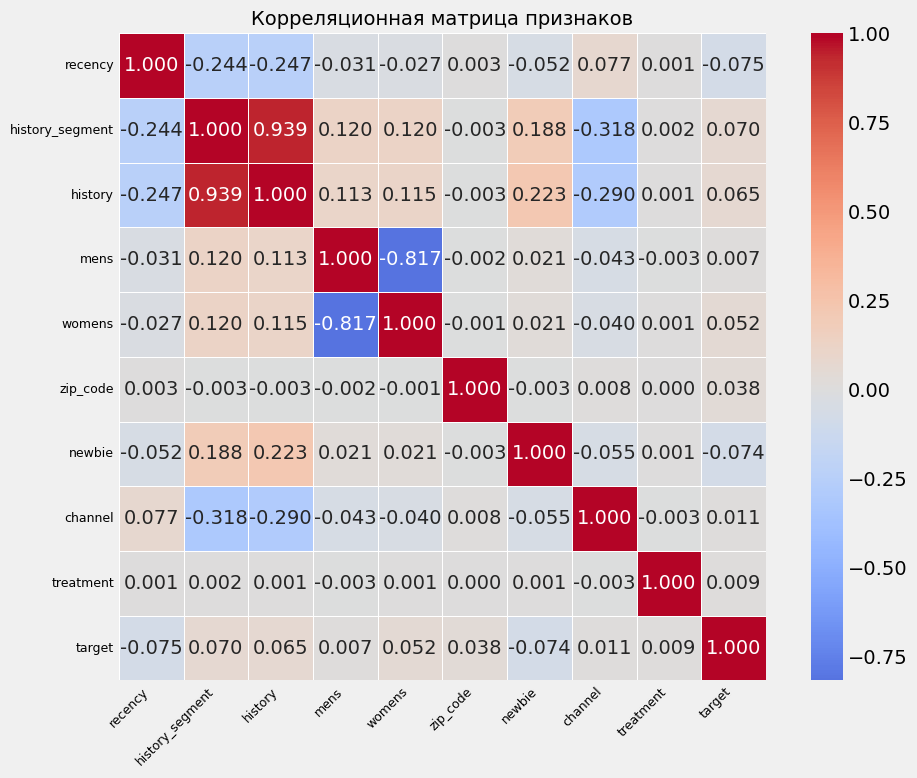

In [32]:
# строим тепловую карту корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5)
plt.title("Корреляционная матрица признаков", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Карта корреляций показывает, что наиболее сильная положительная связь наблюдается между признаками `history_segment` и `history` (`r около 0.94`), что логично, поскольку сегмент расходов формируется на основе объёма покупок. Также заметна сильная отрицательная связь между `mens` и `womens` (`r около -0.82`). Среди остальных признаков выраженных линейных зависимостей нет: корреляции в основном слабые или умеренные. Признак `target` не имеет сильной линейной связи ни с одним отдельным признаком, но всё же рассмотрим отдельно корреляции признаков с целевой переменной, отсортировав их по абсолютной величине.

In [33]:
# рассчитываем корреляции признаков с целевой переменной
target_correlations = (
    corr_matrix["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

In [34]:
# выводим корреляции с таргетом
display(target_correlations.to_frame(name="Корреляция с target"))

,Корреляция с target
recency,-0.075
newbie,-0.074
history_segment,0.070
history,0.065
womens,0.052
zip_code,0.038
channel,0.011
treatment,0.009
mens,0.007


Наиболее выраженную линейную связь с целевой переменной имеют признаки `recency` (`-0.075`), `newbie` (`-0.074`), `history_segment` (`0.070`) и `history` (`0.065`). Однако все коэффициенты по абсолютной величине малы, поэтому, как мы уже определили в карте корреляций, сильной линейной зависимости между `target` и отдельными признаками не наблюдается. Это означает, что таргет, вероятно, определяется не одним фактором, а сочетанием нескольких характеристик клиента и их взаимодействием с воздействием, что соответствует постановке uplift-задачи.

**Вывод**

<div style="border:solid lightblue 3px; padding: 20px">
    
На этапе исследовательского анализа данных мы изучили структуру выборки, сопоставимость контрольной и тестовой групп, различия в конверсии и взаимосвязи между признаками.

Контрольная и тестовая группы хорошо сопоставимы по исходным характеристикам клиентов. Конверсия в группе воздействия составляет 15.1% против 14.4% в контрольной группе. Двухвыборочный z-тест показал, что это различие статистически значимо (`p-value = 0.019`), хотя абсолютный эффект невелик (около 0.7 процентного пункта).

Корреляционный анализ показал сильную связь между `history_segment` и `history` (`r около 0.94`) и сильную отрицательную связь между `mens` и `womens` (`r около -0.82`). При этом ни один отдельный признак не имеет сильной линейной связи с `target`: наиболее выраженные корреляции наблюдаются для `recency`, `newbie`, `history_segment` и `history`, но их абсолютные значения остаются небольшими.

Полученные результаты подтверждают целесообразность uplift-моделирования: средний эффект воздействия положительный, но невелик, а целевая переменная, вероятно, зависит от сочетания характеристик клиента и их взаимодействия с воздействием. На следующем этапе построим бейзлайн uplift-модели и сравним несколько подходов по метрикам `uplift AUC`, `Qini AUC` и `Uplift@30%`.

## Этап 3

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг

Пример использования маппинга:
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

В качестве baseline выберем `S-learner` с `RandomForestClassifier` в качестве базового алгоритма. S-learner является одним из наиболее простых и интерпретируемых подходов к uplift-моделированию: одна модель обучается одновременно на признаках клиента и индикаторе воздействия, а uplift рассчитывается как разница прогнозов для одного и того же объекта при `treatment = 1` и `treatment = 0`. Такой подход удобно использовать как отправную точку для последующего сравнения с более сложными методами.

По результатам EDA ни один отдельный признак не имеет сильной линейной связи с `target`, поэтому в качестве базового алгоритма используем `RandomForestClassifier`, способный учитывать нелинейные зависимости и взаимодействия между признаками. Кроме того, алгоритм позволяет получить важность признаков, что необходимо по условию проекта.

Для сравнения с baseline далее обучим `T-learner` и `X-learner` с тем же базовым алгоритмом и одинаковыми гиперпараметрами. Это позволит оценить влияние самого uplift-подхода на качество модели при неизменной базовой модели.

### Разбиение выборки на тренировочную и тестовую

Разделим данные на тренировочную и тестовую выборки в соотношении 80/20. Для сохранения структуры A/B-теста выполним стратификацию одновременно по признаку воздействия `treatment` и целевой переменной `target`.

In [35]:
# создаём комбинированный признак для стратификации по treatment и target
stratify_group = (
    data["treatment"].astype(str)
    + "_"
    + data["target"].astype(str)
)

In [36]:
# разбиваем исходные данные на тренировочную и тестовую выборки
train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_group
)

In [37]:
# выводим размеры полученных выборок
print(f"Размер тренировочной выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")

Размер тренировочной выборки: (51200, 10)
Размер тестовой выборки: (12800, 10)


Проверим, что после разбиения в тренировочной и тестовой выборках сохранились пропорции всех четырёх комбинаций `treatment × target`.

In [38]:
# рассчитываем доли комбинаций treatment и target в исходной выборке
full_distribution = (
    data.groupby(["treatment", "target"])
    .size()
    .div(len(data))
    .rename("Исходная выборка")
)

In [39]:
# рассчитываем доли комбинаций treatment и target в тренировочной выборке
train_distribution = (
    train_data.groupby(["treatment", "target"])
    .size()
    .div(len(train_data))
    .rename("Train")
)

In [40]:
# рассчитываем доли комбинаций treatment и target в тестовой выборке
test_distribution = (
    test_data.groupby(["treatment", "target"])
    .size()
    .div(len(test_data))
    .rename("Test")
)

In [41]:
# объединяем результаты проверки
split_distribution = pd.concat(
    [
        full_distribution,
        train_distribution,
        test_distribution
    ],
    axis=1
)

In [42]:
# выводим распределение после разбиения
display(split_distribution)

Исходная выборка  Train  Test
treatment target                               
0         0                  0.570  0.570 0.570
          1                  0.096  0.096 0.096
1         0                  0.284  0.284 0.284
          1                  0.051  0.051 0.051

Данные успешно разделены на тренировочную и тестовую выборки в соотношении 80/20. Стратификация одновременно по `treatment` и `target` сохранила исходные пропорции всех четырёх комбинаций в обеих выборках, поэтому структура A/B-теста после разбиения не искажена. Далее можем переходить к подготовке данных для дальнейшего обучения моделей.

### Подготовка данных

Подготовим признаки, целевую переменную и индикатор воздействия для обучения бейзлайна. Зафиксируем явный порядок признаков, чтобы одинаково использовать его при обучении, оценке и дальнейшем инференсе.

In [43]:
# задаём явный порядок признаков для обучения моделей
FEATURES = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
]

In [44]:
# выделяем признаки тренировочной и тестовой выборок
X_train = train_data[FEATURES].copy()
X_test = test_data[FEATURES].copy()

In [45]:
# выделяем целевую переменную
y_train = train_data["target"].astype(int).copy()
y_test = test_data["target"].astype(int).copy()

In [46]:
# выделяем индикатор воздействия
treatment_train = train_data["treatment"].astype(int).copy()
treatment_test = test_data["treatment"].astype(int).copy()

In [47]:
# выводим размеры подготовленных объектов
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"treatment_train: {treatment_train.shape}")
print(f"treatment_test: {treatment_test.shape}")

X_train: (51200, 8)
X_test: (12800, 8)
y_train: (51200,)
y_test: (12800,)
treatment_train: (51200,)
treatment_test: (12800,)


In [48]:
# проверяем порядок признаков
assert list(X_train.columns) == FEATURES
assert list(X_test.columns) == FEATURES

# проверяем совпадение индексов между признаками, таргетом и воздействием
assert X_train.index.equals(y_train.index)
assert X_train.index.equals(treatment_train.index)
assert X_test.index.equals(y_test.index)
assert X_test.index.equals(treatment_test.index)

Данные успешно подготовлены для обучения uplift-моделей. Признаки, целевая переменная и индикатор воздействия разделены корректно, порядок признаков зафиксирован, а индексы между соответствующими объектами совпадают.

### Обучение baseline S-learner

Подготовим индикатор воздействия в формате, ожидаемом библиотекой `causalml`, зададим единые гиперпараметры базового алгоритма и обучим baseline S-learner. Перед обучением проверим корректность входных данных.

In [49]:
# создаём маппинг воздействия для моделей causalml
treatment_mapping = {
    0: "control",
    1: "treatment"
}

In [50]:
# преобразуем treatment в категориальный формат
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

In [51]:
# проверяем отсутствие пропусков в данных для обучения
assert not X_train.isna().any().any()
assert not y_train.isna().any()
assert not treatment_train_mapped.isna().any()

In [52]:
# проверяем корректность значений таргета и воздействия
assert set(y_train.unique()) == {0, 1}
assert set(treatment_train_mapped.unique()) == {"control", "treatment"}

In [53]:
# задаём единые гиперпараметры Random Forest для всех uplift-моделей
RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": 8,
    "min_samples_leaf": 20,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [54]:
# создаём базовый алгоритм
s_base_learner = RandomForestClassifier(**RF_PARAMS)

In [55]:
# создаём baseline S-learner
s_learner = BaseSClassifier(
    learner=s_base_learner,
    control_name="control"
)

In [56]:
# обучаем baseline S-learner
s_learner.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train
)

Обучение baseline S-learner прошло успешно. Перейдём к получению uplift-прогнозов на тренировочной и тестовой выборках, проверим их корректность и затем рассчитаем основные метрики качества модели: `uplift AUC`, `Qini AUC` и `Uplift@30%`.

Для начала проверим размерность прогнозов, а также отсутствие пропущенных и бесконечных значений.

In [57]:
# получаем uplift-прогнозы для тренировочной выборки
s_uplift_train = s_learner.predict(X_train).squeeze()

In [58]:
# получаем uplift-прогнозы для тестовой выборки
s_uplift_test = s_learner.predict(X_test).squeeze()

In [59]:
# проверяем размерность прогнозов
assert s_uplift_train.shape == (len(X_train),)
assert s_uplift_test.shape == (len(X_test),)

In [60]:
# проверяем отсутствие пропущенных и бесконечных значений
assert np.isfinite(s_uplift_train).all()
assert np.isfinite(s_uplift_test).all()

In [61]:
# выводим основные характеристики uplift-прогнозов
print(f"Train uplift shape: {s_uplift_train.shape}")
print(f"Test uplift shape: {s_uplift_test.shape}")

print(
    f"\nTrain uplift: min={s_uplift_train.min():.3f}, "
    f"mean={s_uplift_train.mean():.3f}, "
    f"max={s_uplift_train.max():.3f}"
)

print(
    f"Test uplift: min={s_uplift_test.min():.3f}, "
    f"mean={s_uplift_test.mean():.3f}, "
    f"max={s_uplift_test.max():.3f}"
)

Train uplift shape: (51200,)
Test uplift shape: (12800,)

Train uplift: min=-0.074, mean=0.005, max=0.064
Test uplift: min=-0.074, mean=0.006, max=0.064


Uplift-прогнозы успешно получены для тренировочной и тестовой выборок. Размерности прогнозов соответствуют размерам выборок, пропущенные и бесконечные значения отсутствуют. Диапазон и среднее значение uplift на train и test близки, что на данном этапе не указывает на выраженную нестабильность модели.

### Расчет метрик для baseline S-learner

Рассчитаем основные метрики качества baseline S-learner на тестовой выборке: `uplift AUC`, `Qini AUC` и `Uplift@30%`. Полученные значения сохраним в отдельные переменные для последующего сравнения трёх uplift-моделей.

In [62]:
# рассчитываем uplift AUC на тестовой выборке
s_test_uplift_auc = uplift_auc_score(
    y_true=y_test,
    uplift=s_uplift_test,
    treatment=treatment_test
)

In [63]:
# рассчитываем Qini AUC на тестовой выборке
s_test_qini_auc = qini_auc_score(
    y_true=y_test,
    uplift=s_uplift_test,
    treatment=treatment_test
)

In [64]:
# рассчитываем Uplift@30% на тестовой выборке
s_test_uplift_at_30 = uplift_at_k(
    y_true=y_test,
    uplift=s_uplift_test,
    treatment=treatment_test,
    strategy="overall",
    k=0.30
)

In [65]:
# выводим результаты
print(f"Uplift AUC: {s_test_uplift_auc:.3f}")
print(f"Qini AUC: {s_test_qini_auc:.3f}")
print(f"Uplift@30%: {s_test_uplift_at_30:.3f}")

Uplift AUC: 0.027
Qini AUC: 0.061
Uplift@30%: 0.045


Baseline S-learner показал положительное качество ранжирования: `Uplift AUC = 0.027`, `Qini AUC = 0.061`, а `Uplift@30% = 0.045`. Это означает, что модель способна выделять пользователей с более высоким ожидаемым эффектом воздействия.

Значение `Uplift@30% = 0.045` уже соответствует уровню «хорошо» по критериям финальной части проекта, однако на текущем этапе это только baseline, который далее будет сравниваться с другими uplift-подходами.

Оценим важность признаков baseline S-learner. Поскольку S-learner использует индикатор воздействия вместе с исходными характеристиками клиентов, включим `treatment` в список признаков и визуализируем вклад каждого из них в предсказания базового алгоритма.

In [66]:
# извлекаем обученную базовую модель S-learner
s_fitted_model = s_learner.models["treatment"]

In [67]:
# задаём порядок признаков с учётом treatment, добавляемого S-learner
s_feature_names = ["treatment"] + FEATURES

In [68]:
# извлекаем важность признаков
s_feature_importances = s_fitted_model.feature_importances_

In [69]:
# проверяем соответствие количества признаков и значений важности
assert len(s_feature_importances) == len(s_feature_names)

In [70]:
# создаём и выводим таблицу важности признаков
s_feature_importance = (
    pd.DataFrame({
        "feature": s_feature_names,
        "importance": s_feature_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(s_feature_importance)

,feature,importance
0,history,0.298
1,recency,0.170
2,newbie,0.135
3,history_segment,0.082
4,zip_code,0.079
5,mens,0.073
6,womens,0.062
7,channel,0.058
8,treatment,0.044


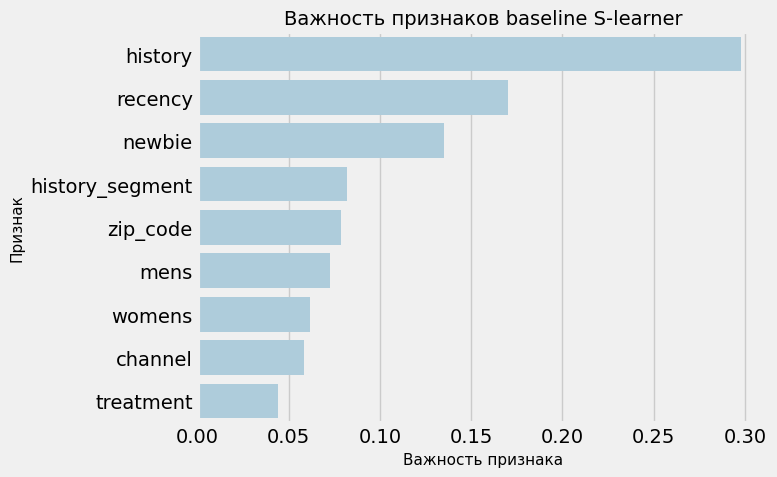

In [71]:
# строим график важности признаков
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=s_feature_importance,
    x="importance",
    y="feature",
    ax=ax)
ax.set_title("Важность признаков baseline S-learner", fontsize=14)
ax.set_xlabel("Важность признака", fontsize=11)
ax.set_ylabel("Признак", fontsize=11)
plt.tight_layout()
plt.show()

Наибольшую важность для baseline S-learner имеют признаки `history`, `recency` и `newbie`. Это указывает на то, что накопленная история взаимодействий, давность последней активности и статус нового клиента сильнее всего влияют на предсказания бейзлайна.

Признак `treatment` также используется моделью, однако его важность ниже, чем у большинства клиентских характеристик. В совокупности это подтверждает, что S-learner учитывает как свойства клиента, так и факт воздействия при построении uplift-прогноза.

Сохраним параметры, метрики и артефакты baseline S-learner в MLflow. Для проекта будем использовать существующий MLflow Tracking Server и отдельный эксперимент, чтобы далее логировать S-learner, T-learner, X-learner и улучшенные модели в едином формате.

In [72]:
# задаём адрес существующего MLflow Tracking Server
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

# задаём название эксперимента текущего проекта
MLFLOW_EXPERIMENT_NAME = "uplift_modeling_tatplet"

# подключаемся к MLflow Tracking Server
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# создаём эксперимент или подключаемся к существующему
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

<Experiment: artifact_location='s3://s3-student-mle-20260520-06bc941798-freetrack/8', creation_time=1789490980433, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1789490980433, lifecycle_stage='active', name='uplift_modeling_tatplet', tags={}, trace_location=None, workspace='default'>

Чтобы повторный запуск ноутбука не создавал дубли одинаковых моделей в MLflow, перед новым логированием будем удалять предыдущий run с тем же именем из текущего эксперимента.

In [73]:
# получаем идентификатор текущего MLflow-эксперимента
mlflow_experiment = mlflow.get_experiment_by_name(
    MLFLOW_EXPERIMENT_NAME
)

MLFLOW_EXPERIMENT_ID = mlflow_experiment.experiment_id


# создаём функцию для удаления предыдущего run с тем же именем
def delete_existing_mlflow_run(run_name):
    existing_runs = mlflow.search_runs(
        experiment_ids=[MLFLOW_EXPERIMENT_ID],
        filter_string=f"tags.mlflow.runName = '{run_name}'"
    )

    # удаляем найденные активные runs с тем же именем
    for run_id in existing_runs["run_id"]:
        mlflow.delete_run(run_id)

Далее залогируем наш бейзлайн в MLflow: сохраним тип uplift-модели, параметры базового Random Forest, значения основных uplift-метрик и график важности признаков.

In [74]:
# задаём имя MLflow-run для baseline S-learner
S_RUN_NAME = "baseline_s_learner_random_forest"

# удаляем предыдущий run с тем же именем при повторном запуске ноутбука
delete_existing_mlflow_run(S_RUN_NAME)

# запускаем MLflow-run для baseline S-learner
with mlflow.start_run(run_name=S_RUN_NAME) as run:
    # логируем тип uplift-модели и базового алгоритма
    mlflow.log_param("uplift_model", "S-learner")
    mlflow.log_param("base_learner", "RandomForestClassifier")

    # логируем гиперпараметры базового алгоритма
    for param_name, param_value in RF_PARAMS.items():
        mlflow.log_param(param_name, param_value)

    # логируем uplift-метрики
    mlflow.log_metric("uplift_auc", s_test_uplift_auc)
    mlflow.log_metric("qini_auc", s_test_qini_auc)
    mlflow.log_metric("uplift_at_30", s_test_uplift_at_30)

    # логируем график важности признаков
    mlflow.log_figure(
        fig,
        "feature_importance.png")

    # сохраняем идентификатор запуска
    s_mlflow_run_id = run.info.run_id
print(f"MLflow run ID: {s_mlflow_run_id}")

🏃 View run baseline_s_learner_random_forest at: http://127.0.0.1:5000/#/experiments/8/runs/c67347b78090422281e77743c7e752d2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8
MLflow run ID: c67347b78090422281e77743c7e752d2


Baseline S-learner успешно залогирован в MLflow. В эксперимент сохранены параметры модели, значения `Uplift AUC`, `Qini AUC`, `Uplift@30%` и график важности признаков. Переходим к обучению следующей модели.

### Обучение T-learner

Для сравнения с baseline обучим `T-learner` с тем же базовым алгоритмом `RandomForestClassifier` и теми же гиперпараметрами. В отличие от S-learner, T-learner обучает отдельные модели для контрольной и экспериментальной групп, а uplift рассчитывается как разница между их прогнозами.

In [75]:
# создаём базовый алгоритм для T-learner
t_base_learner = RandomForestClassifier(**RF_PARAMS)

In [76]:
# создаём T-learner
t_learner = BaseTClassifier(
    learner=t_base_learner,
    control_name="control"
)

In [77]:
# обучаем T-learner
t_learner.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train
)

Обучение T-learner прошло успешно. Перейдём к получению uplift-прогнозов на тренировочной и тестовой выборках, проверим их корректность и затем рассчитаем основные метрики качества.

### Расчет метрик для T-learner

Получим uplift-прогнозы T-learner для тренировочной и тестовой выборок и также проверим их корректность.

In [78]:
# получаем uplift-прогнозы для тренировочной выборки
t_uplift_train = t_learner.predict(X_train).squeeze()

/home/mle-user/mle_projects/mle-project-sprint-5-v001/uplift_project_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/mle-user/mle_projects/mle-project-sprint-5-v001/uplift_project_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [79]:
# получаем uplift-прогнозы для тестовой выборки
t_uplift_test = t_learner.predict(X_test).squeeze()

/home/mle-user/mle_projects/mle-project-sprint-5-v001/uplift_project_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/mle-user/mle_projects/mle-project-sprint-5-v001/uplift_project_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [80]:
# проверяем размерность прогнозов
assert t_uplift_train.shape == (len(X_train),)
assert t_uplift_test.shape == (len(X_test),)

In [81]:
# проверяем отсутствие пропущенных и бесконечных значений
assert np.isfinite(t_uplift_train).all()
assert np.isfinite(t_uplift_test).all()

In [82]:
# выводим основные характеристики uplift-прогнозов
print(f"Train uplift shape: {t_uplift_train.shape}")
print(f"Test uplift shape: {t_uplift_test.shape}")

print(
    f"\nTrain uplift: min={t_uplift_train.min():.3f}, "
    f"mean={t_uplift_train.mean():.3f}, "
    f"max={t_uplift_train.max():.3f}"
)

print(
    f"Test uplift: min={t_uplift_test.min():.3f}, "
    f"mean={t_uplift_test.mean():.3f}, "
    f"max={t_uplift_test.max():.3f}"
)

Train uplift shape: (51200,)
Test uplift shape: (12800,)

Train uplift: min=-0.165, mean=0.007, max=0.179
Test uplift: min=-0.162, mean=0.007, max=0.157


Uplift-прогнозы T-learner успешно получены для тренировочной и тестовой выборок. Размерности прогнозов соответствуют размерам выборок, пропущенные и бесконечные значения отсутствуют. Диапазон и среднее значение uplift на train и test близки.

Теперь рассчитаем метрики качества T-learner на тестовой выборке: `Uplift AUC`, `Qini AUC` и `Uplift@30%`. Полученные значения сохраним в отдельные переменные для последующего сравнения uplift-моделей.

In [83]:
# рассчитываем uplift AUC на тестовой выборке
t_test_uplift_auc = uplift_auc_score(
    y_true=y_test,
    uplift=t_uplift_test,
    treatment=treatment_test
)

In [84]:
# рассчитываем Qini AUC на тестовой выборке
t_test_qini_auc = qini_auc_score(
    y_true=y_test,
    uplift=t_uplift_test,
    treatment=treatment_test
)

In [85]:
# рассчитываем Uplift@30% на тестовой выборке
t_test_uplift_at_30 = uplift_at_k(
    y_true=y_test,
    uplift=t_uplift_test,
    treatment=treatment_test,
    strategy="overall",
    k=0.30
)

In [86]:
# выводим метрики T-learner
print(f"Uplift AUC: {t_test_uplift_auc:.3f}")
print(f"Qini AUC: {t_test_qini_auc:.3f}")
print(f"Uplift@30%: {t_test_uplift_at_30:.3f}")

Uplift AUC: 0.028
Qini AUC: 0.063
Uplift@30%: 0.055


T-learner показал `Uplift AUC = 0.028`, `Qini AUC = 0.063` и `Uplift@30% = 0.055`. По сравнению с baseline S-learner значения всех трёх метрик немного выше, а `Uplift@30%` вырос с `0.045` до `0.055`.

Таким образом, T-learner на текущем этапе лучше выделяет клиентов с высоким ожидаемым эффектом воздействия и показывает более сильный результат в верхних 30% ранжирования.

Залогируем T-learner в MLflow: сохраним тип uplift-модели, параметры базового Random Forest и значения основных uplift-метрик.

In [87]:
# задаём имя MLflow-run для T-learner
T_RUN_NAME = "t_learner_random_forest"

# удаляем предыдущий run с тем же именем при повторном запуске ноутбука
delete_existing_mlflow_run(T_RUN_NAME)

# запускаем MLflow-run для T-learner
with mlflow.start_run(run_name=T_RUN_NAME) as run:
    # логируем тип uplift-модели и базового алгоритма
    mlflow.log_param("uplift_model", "T-learner")
    mlflow.log_param("base_learner", "RandomForestClassifier")

    # логируем гиперпараметры базового алгоритма
    for param_name, param_value in RF_PARAMS.items():
        mlflow.log_param(param_name, param_value)

    # логируем uplift-метрики
    mlflow.log_metric("uplift_auc", t_test_uplift_auc)
    mlflow.log_metric("qini_auc", t_test_qini_auc)
    mlflow.log_metric("uplift_at_30", t_test_uplift_at_30)

    # сохраняем идентификатор запуска
    t_mlflow_run_id = run.info.run_id

print(f"MLflow run ID: {t_mlflow_run_id}")

🏃 View run t_learner_random_forest at: http://127.0.0.1:5000/#/experiments/8/runs/74bd5ff5e0354d7781ef886c4705cfde
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8
MLflow run ID: 74bd5ff5e0354d7781ef886c4705cfde


T-learner успешно залогирован в MLflow. В эксперимент сохранены тип uplift-модели, параметры базового `RandomForestClassifier` и значения `Uplift AUC`, `Qini AUC` и `Uplift@30%`. И теперь переходим к обучению третьей модели.

### Обучение X-learner

Для X-learner используем `RandomForestClassifier` для моделирования исхода и `RandomForestRegressor` для моделирования индивидуального эффекта воздействия. Для обоих алгоритмов сохраняем те же основные гиперпараметры Random Forest, чтобы сравнение с предыдущими uplift-подходами оставалось максимально сопоставимым.

In [88]:
# создаём модель исхода для X-learner
x_outcome_learner = RandomForestClassifier(**RF_PARAMS)

In [89]:
# создаём модель эффекта для X-learner
x_effect_learner = RandomForestRegressor(**RF_PARAMS)

In [90]:
# создаём X-learner
x_learner = BaseXClassifier(
    outcome_learner=x_outcome_learner,
    effect_learner=x_effect_learner,
    control_name="control"
)

Поскольку данные получены из рандомизированного A/B-теста, вероятность попадания пользователя в treatment-группу можно считать известной и не моделировать отдельно по признакам. Используем постоянный propensity score, равный доле treatment-группы в тренировочной выборке.

In [91]:
# рассчитываем вероятность попадания в treatment-группу
treatment_probability = treatment_train.mean()

# создаём propensity score для тренировочной выборки
p_train = np.full(
    len(X_train),
    treatment_probability)
print(f"Treatment probability: {treatment_probability:.3f}")

Treatment probability: 0.334


In [92]:
# обучаем X-learner с известным propensity score
x_learner.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train,
    p=p_train
)

X-learner успешно обучен с использованием известного propensity score, соответствующего доле treatment-группы в тренировочной выборке.

### Расчет метрик для X-learner

Получим uplift-прогнозы X-learner для тренировочной и тестовой выборок и проверим их корректность.

In [93]:
# получаем uplift-прогнозы для тренировочной выборки
x_uplift_train = x_learner.predict(X_train, p=p_train).squeeze()

In [94]:
# создаём propensity score для тестовой выборки
p_test = np.full(
    len(X_test),
    treatment_probability
)

In [95]:
# получаем uplift-прогнозы для тестовой выборки
x_uplift_test = x_learner.predict(X_test, p=p_test).squeeze()

In [96]:
# проверяем размерность прогнозов
assert x_uplift_train.shape == (len(X_train),)
assert x_uplift_test.shape == (len(X_test),)

In [97]:
# проверяем отсутствие пропущенных и бесконечных значений
assert np.isfinite(x_uplift_train).all()
assert np.isfinite(x_uplift_test).all()

In [98]:
# выводим основные характеристики uplift-прогнозов
print(f"Train uplift shape: {x_uplift_train.shape}")
print(f"Test uplift shape: {x_uplift_test.shape}")

print(
    f"\nTrain uplift: min={x_uplift_train.min():.3f}, "
    f"mean={x_uplift_train.mean():.3f}, "
    f"max={x_uplift_train.max():.3f}"
)

print(
    f"Test uplift: min={x_uplift_test.min():.3f}, "
    f"mean={x_uplift_test.mean():.3f}, "
    f"max={x_uplift_test.max():.3f}"
)

Train uplift shape: (51200,)
Test uplift shape: (12800,)

Train uplift: min=-0.127, mean=0.007, max=0.178
Test uplift: min=-0.115, mean=0.007, max=0.171


Uplift-прогнозы X-learner успешно получены для тренировочной и тестовой выборок. Размерности прогнозов соответствуют размерам выборок, пропущенные и бесконечные значения отсутствуют. Среднее значение uplift на train и test совпадает, а диапазоны прогнозов близки.

Теперь рассчитаем основные метрики качества X-learner на тестовой выборке: `Uplift AUC`, `Qini AUC` и `Uplift@30%`. Полученные значения сохраним для последующего сравнения всех uplift-моделей.

In [99]:
# рассчитываем uplift AUC на тестовой выборке
x_test_uplift_auc = uplift_auc_score(
    y_true=y_test,
    uplift=x_uplift_test,
    treatment=treatment_test
)

In [100]:
# рассчитываем Qini AUC на тестовой выборке
x_test_qini_auc = qini_auc_score(
    y_true=y_test,
    uplift=x_uplift_test,
    treatment=treatment_test
)

In [101]:
# рассчитываем Uplift@30% на тестовой выборке
x_test_uplift_at_30 = uplift_at_k(
    y_true=y_test,
    uplift=x_uplift_test,
    treatment=treatment_test,
    strategy="overall",
    k=0.30
)

In [102]:
# выводим метрики X-learner
print(f"Uplift AUC: {x_test_uplift_auc:.3f}")
print(f"Qini AUC: {x_test_qini_auc:.3f}")
print(f"Uplift@30%: {x_test_uplift_at_30:.3f}")

Uplift AUC: 0.029
Qini AUC: 0.065
Uplift@30%: 0.043


X-learner показал `Uplift AUC = 0.029`, `Qini AUC = 0.065` и `Uplift@30% = 0.043`. По `Uplift AUC` и `Qini AUC` модель немного превосходит S-learner и T-learner, однако значение `Uplift@30%` ниже, чем у T-learner (`0.055`) и baseline S-learner (`0.045`).

Таким образом, X-learner лучше ранжирует клиентов по uplift в целом, но хуже выделяет наиболее перспективные верхние 30% аудитории. Для бизнес-задачи таргетирования промо это делает T-learner более сильным кандидатом на текущем этапе.

Залогируем X-learner в MLflow: сохраним тип uplift-модели, используемые базовые алгоритмы и значения основных uplift-метрик.

In [103]:
# задаём имя MLflow-run для X-learner
X_RUN_NAME = "x_learner_random_forest"

# удаляем предыдущий run с тем же именем при повторном запуске ноутбука
delete_existing_mlflow_run(X_RUN_NAME)

# запускаем MLflow-run для X-learner
with mlflow.start_run(run_name=X_RUN_NAME) as run:
    # логируем тип uplift-модели и базовые алгоритмы
    mlflow.log_param("uplift_model", "X-learner")
    mlflow.log_param("outcome_learner", "RandomForestClassifier")
    mlflow.log_param("effect_learner", "RandomForestRegressor")

    # логируем гиперпараметры Random Forest
    for param_name, param_value in RF_PARAMS.items():
        mlflow.log_param(param_name, param_value)

    # логируем propensity score
    mlflow.log_param(
        "treatment_probability",
        treatment_probability
    )

    # логируем uplift-метрики
    mlflow.log_metric("uplift_auc", x_test_uplift_auc)
    mlflow.log_metric("qini_auc", x_test_qini_auc)
    mlflow.log_metric("uplift_at_30", x_test_uplift_at_30)

    # сохраняем идентификатор запуска
    x_mlflow_run_id = run.info.run_id

print(f"MLflow run ID: {x_mlflow_run_id}")

🏃 View run x_learner_random_forest at: http://127.0.0.1:5000/#/experiments/8/runs/dff8058e9af9469194da26aedb1e663e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8
MLflow run ID: dff8058e9af9469194da26aedb1e663e


X-learner успешно залогирован в MLflow. В эксперимент сохранены тип uplift-модели, базовые алгоритмы для моделирования исхода и эффекта воздействия, propensity score, параметры Random Forest и значения основных uplift-метрик. Теперь сравним все 3 модели по вышерассчитанным метрикам.

### Сравнение трёх моделей и выбор лучшей

Сравним качество S-learner, T-learner и X-learner по основным uplift-метрикам на тестовой выборке.

In [104]:
# создаём таблицу сравнения uplift-моделей
model_comparison = pd.DataFrame({
    "model": [
        "S-learner",
        "T-learner",
        "X-learner"
    ],
    "uplift_auc": [
        s_test_uplift_auc,
        t_test_uplift_auc,
        x_test_uplift_auc
    ],
    "qini_auc": [
        s_test_qini_auc,
        t_test_qini_auc,
        x_test_qini_auc
    ],
    "uplift_at_30": [
        s_test_uplift_at_30,
        t_test_uplift_at_30,
        x_test_uplift_at_30
    ]
})

# выводим сравнительную таблицу
display(model_comparison)

,model,uplift_auc,qini_auc,uplift_at_30
0,S-learner,0.027,0.061,0.045
1,T-learner,0.028,0.063,0.055
2,X-learner,0.029,0.065,0.043


Также визуализируем результаты сравнения uplift-моделей, чтобы наглядно сопоставить их по основным метрикам на тестовой выборке.

In [105]:
# создаём таблицу в длинном формате для построения графика
comparison_plot_df = model_comparison.melt(
    id_vars="model",
    value_vars=["uplift_auc", "qini_auc", "uplift_at_30"],
    var_name="metric",
    value_name="value"
)

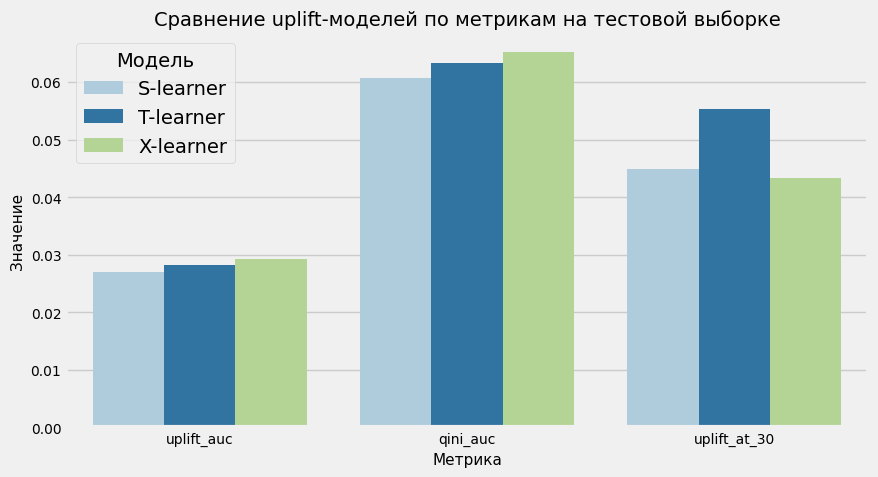

In [106]:
# строим столбчатую диаграмму
plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_plot_df,
    x="metric",
    y="value",
    hue="model"
)

# задаём оформление графика
plt.title("Сравнение uplift-моделей по метрикам на тестовой выборке", fontsize=14)
plt.xlabel("Метрика", fontsize=11)
plt.ylabel("Значение", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Модель")
plt.tight_layout()
plt.show()

По результатам сравнения X-learner показывает лучшие значения `Uplift AUC` (`0.029`) и `Qini AUC` (`0.065`), то есть немного лучше ранжирует пользователей по ожидаемому эффекту воздействия в целом. При этом T-learner показывает наилучший `Uplift@30%` (`0.055`) против `0.045` у S-learner и `0.043` у X-learner. Поскольку бизнес-задача связана с выбором наиболее перспективной части аудитории для промо, именно T-learner на текущем этапе является наиболее сильным кандидатом.

**Вывод**

<div style="border:solid lightblue 3px; padding: 20px">
    
На данном этапе были обучены и сопоставлены три uplift-подхода: S-learner, T-learner и X-learner. Для корректного сравнения использовался единый базовый алгоритм семейства Random Forest и одинаковые основные гиперпараметры. Качество моделей оценивалось на тестовой выборке с помощью `Uplift AUC`, `Qini AUC` и `Uplift@30%`.

Baseline S-learner показал `Uplift AUC = 0.027`, `Qini AUC = 0.061` и `Uplift@30% = 0.045`. T-learner улучшил результаты до `0.028`, `0.063` и `0.055` соответственно. X-learner показал лучшие значения `Uplift AUC = 0.029` и `Qini AUC = 0.065`, однако его `Uplift@30% = 0.043` оказался ниже результатов остальных моделей.

Различия в метриках связаны с архитектурой uplift-подходов. S-learner использует одну общую модель для контрольной и treatment-групп, поэтому индивидуальный эффект воздействия моделируется косвенно и может сглаживаться. T-learner обучает две независимые модели для control и treatment, что позволяет гибче учитывать различия между группами и в данном случае лучше выделять клиентов с высоким uplift в верхних 30% ранжирования. X-learner дополнительно моделирует индивидуальные эффекты воздействия и поэтому несколько лучше ранжирует пользователей в целом по `Uplift AUC` и `Qini AUC`, однако это преимущество не приводит к лучшему результату именно в верхних 30% аудитории.

Таким образом, X-learner несколько лучше ранжирует пользователей по ожидаемому эффекту воздействия в целом, тогда как T-learner наиболее эффективно выделяет верхние 30% клиентов с максимальным ожидаемым uplift. Поскольку бизнес-задача заключается в выборе наиболее перспективной аудитории для промо, **T-learner на текущем этапе является наиболее сильным кандидатом** для дальнейшего улучшения.

Все эксперименты залогированы в MLflow с сохранением параметров и основных uplift-метрик, а для baseline дополнительно сохранён график важности признаков. Следующим шагом станет улучшение выбранной модели и подбор гиперпараметров с использованием релевантной uplift-метрики.

# Часть 2

## Этап 1

Во второй части проекта улучшим выбранную uplift-модель. По результатам первой части лучшим кандидатом для дальнейшей оптимизации стал `T-learner`, показавший максимальное значение `Uplift@30% = 0.055`. Далее сосредоточимся на подборе гиперпараметров модели с оптимизацией по метрике `Uplift@30%`, а финальное качество оценим на ранее отложенной тестовой выборке.

### Подбор гиперпараметров

Для подбора гиперпараметров дополнительно разделим тренировочную выборку на обучающую и валидационную части. Исходную тестовую выборку не будем использовать при оптимизации гиперпараметров и сохраним для финальной оценки улучшенной модели.

In [107]:
# создаём группу для стратификации по воздействию и таргету
stratify_train = (
    train_data["treatment"].astype(str)
    + "_"
    + train_data["target"].astype(str)
)

In [108]:
# разделяем тренировочную выборку на train и validation
train_opt_data, valid_data = train_test_split(
    train_data,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_train
)

In [109]:
# выводим размеры выборок
print(f"Обучающая выборка для оптимизации: {train_opt_data.shape}")
print(f"Валидационная выборка: {valid_data.shape}")
print(f"Финальная тестовая выборка: {test_data.shape}")

Обучающая выборка для оптимизации: (40960, 10)
Валидационная выборка: (10240, 10)
Финальная тестовая выборка: (12800, 10)


Исходная тренировочная выборка дополнительно разделена на обучающую и валидационную части в соотношении 80/20. Для оптимизации гиперпараметров будем использовать 40960 наблюдений для обучения и 10240 для валидации, а исходную тестовую выборку из 12800 наблюдений, как мы указали выше, сохраним только для финальной оценки модели.

Проверим, что стратификация сохранила распределение сочетаний `treatment` и `target` в обучающей и валидационной выборках.

In [110]:
# рассчитываем распределение treatment и target в обучающей выборке
train_opt_distribution = (
    train_opt_data
    .groupby(["treatment", "target"])
    .size()
    .div(len(train_opt_data))
    .rename("Обучение")
)

In [111]:
# рассчитываем распределение treatment и target в валидационной выборке
valid_distribution = (
    valid_data
    .groupby(["treatment", "target"])
    .size()
    .div(len(valid_data))
    .rename("Валидация")
)

In [112]:
# объединяем распределения для сравнения и выводим результат
stratification_check = pd.concat(
    [train_opt_distribution, valid_distribution],
    axis=1)
display(stratification_check)

Обучение  Валидация
treatment target                     
0         0          0.570      0.570
          1          0.096      0.096
1         0          0.284      0.284
          1          0.051      0.051

Распределение сочетаний `treatment` и `target` в обучающей и валидационной выборках совпадает, поэтому стратификация выполнена корректно и структура исходных данных сохранена. Далее подготовим признаки, таргет и индикатор воздействия для обучающей и валидационной выборок. Порядок признаков сохраним тем же, что использовался в первой части проекта.

In [113]:
# формируем признаки обучающей выборки
X_train_opt = train_opt_data[FEATURES].copy()

In [114]:
# формируем признаки валидационной выборки
X_valid = valid_data[FEATURES].copy()

In [115]:
# формируем таргет обучающей выборки
y_train_opt = train_opt_data["target"].astype(int).copy()

In [116]:
# формируем таргет валидационной выборки
y_valid = valid_data["target"].astype(int).copy()

In [117]:
# формируем индикатор воздействия обучающей выборки
treatment_train_opt = train_opt_data["treatment"].astype(int).copy()

In [118]:
# формируем индикатор воздействия валидационной выборки
treatment_valid = valid_data["treatment"].astype(int).copy()

In [119]:
# преобразуем treatment в формат, ожидаемый causalml
treatment_train_opt_mapped = treatment_train_opt.map(treatment_mapping)
treatment_valid_mapped = treatment_valid.map(treatment_mapping)

In [120]:
# проверяем соответствие индексов
assert X_train_opt.index.equals(y_train_opt.index)
assert X_train_opt.index.equals(treatment_train_opt.index)
assert X_valid.index.equals(y_valid.index)
assert X_valid.index.equals(treatment_valid.index)

In [121]:
# проверяем отсутствие пропусков
assert not X_train_opt.isna().any().any()
assert not X_valid.isna().any().any()

In [122]:
# выводим размеры выборок
print(f"Обучающая выборка: {X_train_opt.shape}")
print(f"Валидационная выборка: {X_valid.shape}")

Обучающая выборка: (40960, 8)
Валидационная выборка: (10240, 8)


Признаки, таргет и индикатор воздействия для обучающей и валидационной выборок подготовлены корректно. Размерности соответствуют ожидаемым, порядок признаков сохранён, пропущенные значения отсутствуют.

Для оптимизации преобразуем признаки в NumPy-массивы. Это позволит избежать служебных предупреждений `sklearn` при взаимодействии с внутренними моделями `causalml`, сохранив фиксированный порядок признаков из списка `FEATURES`.

In [123]:
# преобразуем признаки в массивы с сохранением заданного порядка FEATURES
X_train_opt_array = X_train_opt.to_numpy()
X_valid_array = X_valid.to_numpy()

Подберём гиперпараметры T-learner с помощью Optuna. В качестве целевой метрики используем `Uplift@30%` на валидационной выборке, поскольку именно эта метрика является основной для оценки качества модели в данном проекте.

In [124]:
# создаём целевую функцию для Optuna
def objective(trial):
    # подбираем гиперпараметры Random Forest
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 4, 14),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            5,
            50,
            step=5
        ),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    # создаём базовый алгоритм
    base_learner = RandomForestClassifier(**params)

    # создаём T-learner
    model = BaseTClassifier(
        learner=base_learner,
        control_name="control"
    )

    # обучаем модель
    model.fit(
        X=X_train_opt_array,
        treatment=treatment_train_opt_mapped,
        y=y_train_opt
    )

    # получаем uplift-прогнозы на валидационной выборке
    uplift_pred = model.predict(
        X_valid_array
    ).squeeze()

    # рассчитываем Uplift@30% на валидационной выборке
    uplift_at_30 = uplift_at_k(
        y_true=y_valid,
        uplift=uplift_pred,
        treatment=treatment_valid,
        strategy="overall",
        k=0.30
    )

    return uplift_at_30

Перед запуском полноценного подбора гиперпараметров проверим работу целевой функции Optuna на одном тестовом наборе параметров.

In [125]:
# создаём тестовый набор гиперпараметров
test_trial = optuna.trial.FixedTrial({
    "n_estimators": 200,
    "max_depth": 8,
    "min_samples_leaf": 20,
    "max_features": "sqrt"
})

In [126]:
# проверяем работу целевой функции
test_uplift_at_30 = objective(test_trial)
print(f"Тестовый Uplift@30%: {test_uplift_at_30:.3f}")

Тестовый Uplift@30%: 0.050


Целевая функция Optuna работает корректно: на тестовом наборе гиперпараметров получено `Uplift@30% = 0.050` на валидационной выборке. Теперь запустим оптимизацию гиперпараметров T-learner с помощью Optuna. Целью оптимизации является максимизировать `Uplift@30%` на валидационной выборке.

In [127]:
# создаём Optuna study для максимизации Uplift@30%
study = optuna.create_study(
    direction="maximize",
    study_name="t_learner_uplift_at_30"
)

# запускаем подбор гиперпараметров
study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

# выводим лучший результат
print(f"Лучший Uplift@30% на валидации: {study.best_value:.3f}")
print("Лучшие гиперпараметры:")
for param_name, param_value in study.best_params.items():
    print(f"{param_name}: {param_value}")

  0%|          | 0/30 [00:00<?, ?it/s]

Лучший Uplift@30% на валидации: 0.047
Лучшие гиперпараметры:
n_estimators: 350
max_depth: 8
min_samples_leaf: 25
max_features: log2


Подбор гиперпараметров с помощью Optuna не позволил улучшить результат базовой конфигурации T-learner на валидационной выборке: лучший `Uplift@30%` составил `0.047`, тогда как тестовый запуск исходной конфигурации на той же валидационной выборке дал `0.050`. Поэтому исходная конфигурация T-learner с Random Forest пока остаётся лучшим вариантом. Дополнительно проверим альтернативный базовый алгоритм LightGBM внутри той же архитектуры T-learner и сравним модели на одной и той же валидационной выборке.

Проверим, позволит ли более гибкий градиентный бустинг улучшить качество uplift-модели. Для корректного сравнения сохраним архитектуру T-learner и оценим LightGBM на той же валидационной выборке по `Uplift@30%`.

In [128]:
# задаём параметры LightGBM
LGBM_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1
}

In [129]:
# создаём базовый алгоритм
lgbm_learner = LGBMClassifier(**LGBM_PARAMS)

In [130]:
# создаём T-learner с LightGBM
t_learner_lgbm = BaseTClassifier(
    learner=lgbm_learner,
    control_name="control"
)

In [134]:
# обучаем модель
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="'force_all_finite' was renamed to 'ensure_all_finite'",
        category=FutureWarning
    )

    t_learner_lgbm.fit(
        X=X_train_opt_array,
        treatment=treatment_train_opt_mapped,
        y=y_train_opt
    )

In [135]:
# получаем uplift-прогнозы на валидационной выборке
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="'force_all_finite' was renamed to 'ensure_all_finite'",
        category=FutureWarning
    )

    uplift_valid_lgbm = t_learner_lgbm.predict(
        X_valid_array
    ).squeeze()

In [136]:
# рассчитываем Uplift@30%
lgbm_uplift_at_30 = uplift_at_k(
    y_true=y_valid,
    uplift=uplift_valid_lgbm,
    treatment=treatment_valid,
    strategy="overall",
    k=0.30)
print(
    f"T-learner + LightGBM, Uplift@30% на валидации: "
    f"{lgbm_uplift_at_30:.3f}"
)

T-learner + LightGBM, Uplift@30% на валидации: 0.031


T-learner с LightGBM показал `Uplift@30% = 0.031` на валидационной выборке, что является неудовлетворительным результатом по требованиям заказчика. Результат также ниже контрольного запуска T-learner с Random Forest на той же валидационной выборке (`0.050`), выполненного при проверке целевой функции Optuna, а также ниже лучшего результата после подбора гиперпараметров (`0.047`).

Таким образом, дополнительный эксперимент с LightGBM не позволил улучшить качество модели. Для дальнейшей работы сохраняем исходную конфигурацию T-learner с Random Forest, которая была выбрана лучшей моделью в первой части проекта с `Uplift@30% = 0.055` на тестовой выборке.

По результатам экспериментов сохраняем исходную конфигурацию T-learner с Random Forest. Обучим финальную модель на всей тренировочной выборке и оценим её качество на отложенной тестовой выборке.

In [137]:
# преобразуем признаки в массивы с сохранением порядка FEATURES
X_train_array = X_train.to_numpy()
X_test_array = X_test.to_numpy()

In [138]:
# создаём базовый алгоритм с исходными параметрами
final_rf_learner = RandomForestClassifier(**RF_PARAMS)

In [139]:
# создаём финальный T-learner
final_t_learner = BaseTClassifier(
    learner=final_rf_learner,
    control_name="control"
)

In [140]:
# обучаем финальную модель на всей тренировочной выборке
final_t_learner.fit(
    X=X_train_array,
    treatment=treatment_train_mapped,
    y=y_train
)

In [141]:
# получаем uplift-прогнозы на тестовой выборке
final_uplift_test = final_t_learner.predict(
    X_test_array
).squeeze()

In [142]:
# рассчитываем финальные uplift-метрики
final_uplift_auc = uplift_auc_score(
    y_true=y_test,
    uplift=final_uplift_test,
    treatment=treatment_test
)

final_qini_auc = qini_auc_score(
    y_true=y_test,
    uplift=final_uplift_test,
    treatment=treatment_test
)

final_uplift_at_30 = uplift_at_k(
    y_true=y_test,
    uplift=final_uplift_test,
    treatment=treatment_test,
    strategy="overall",
    k=0.30
)

In [143]:
# выводим результаты
print(f"Uplift AUC: {final_uplift_auc:.3f}")
print(f"Qini AUC: {final_qini_auc:.3f}")
print(f"Uplift@30%: {final_uplift_at_30:.3f}")

Uplift AUC: 0.028
Qini AUC: 0.063
Uplift@30%: 0.055


Финальная модель T-learner с Random Forest показала на тестовой выборке `Uplift AUC = 0.028`, `Qini AUC = 0.063` и `Uplift@30% = 0.055`. Значение `Uplift@30%` соответствует высокому уровню качества по требованиям заказчика (Uplift@30 >= 0.050).

Залогируем финальную модель T-learner с Random Forest и её метрики на тестовой выборке в MLflow.

In [144]:
# задаём имя финального MLflow run
final_run_name = "final_t_learner_random_forest"

# удаляем предыдущий run с таким именем при повторном запуске ноутбука
delete_existing_mlflow_run(final_run_name)

# создаём MLflow run
with mlflow.start_run(run_name=final_run_name) as run:
    # логируем тип модели
    mlflow.log_param("uplift_model", "T-learner")
    mlflow.log_param("base_learner", "RandomForestClassifier")

    # логируем параметры Random Forest
    for param_name, param_value in RF_PARAMS.items():
        mlflow.log_param(param_name, param_value)

    # логируем финальные метрики на тестовой выборке
    mlflow.log_metric("uplift_auc", final_uplift_auc)
    mlflow.log_metric("qini_auc", final_qini_auc)
    mlflow.log_metric("uplift_at_30", final_uplift_at_30)

    # добавляем служебные теги
    mlflow.set_tag("model_stage", "final")
    mlflow.set_tag("evaluation_split", "test")

    final_run_id = run.info.run_id

# выводим идентификатор созданного run
print(f"MLflow run успешно создан: {final_run_id}")

🏃 View run final_t_learner_random_forest at: http://127.0.0.1:5000/#/experiments/8/runs/e93862ceae2a42dbbfcaa51f58fc6632
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8
MLflow run успешно создан: e93862ceae2a42dbbfcaa51f58fc6632


Финальная модель T-learner с Random Forest успешно залогирована в MLflow вместе с параметрами и итоговыми метриками на тестовой выборке.

## Этап 2

### Визуализация результатов

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [ ]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [ ]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)